In [20]:
from preprocessors import BoundingBoxEngineering
from PIL import Image
import pandas as pd
import numpy as np

# Extracting bounding boxes
We developed a class to identify and extract N bounding boxes from a video frame. The intention is to use this class in a pipeline to encapsulate the logic and improve consistency. Under the hood, the BoundingBoxEngineering class uses YOLO 11 to find all bounding boxes for pedestrians and traffic signals in a given frame. For each bounding boxes it collects the width, height, X, Y coordinates, and a classification of the object. In addition, the BoundingBoxEngineering class collects the vectorized image, shaped (128, 128, 3), of the subject. The final 4D array has a shape of (rows, bounding-boxes, width, height, channels+metadata) -> (N, 10, 128, 128, 8). 

It's also worth metioning that the vector is normalized between 0-1. The metadata elements are normalized against the original image size.

![BoundingBoxEngineering class diagram](../docs/Gemini_Generated_Image_h2h6bnh2h6bnh2h6.png)

# Example running the bounding box transformer step

The following example shows how to convert an image into to the vector we need to processing in our model pipeline. We are going to look up a PNG with a pedestrian and extract a three bounding boxes. This image only contains over a dozen bounding boxes but we'll extract three for testing.

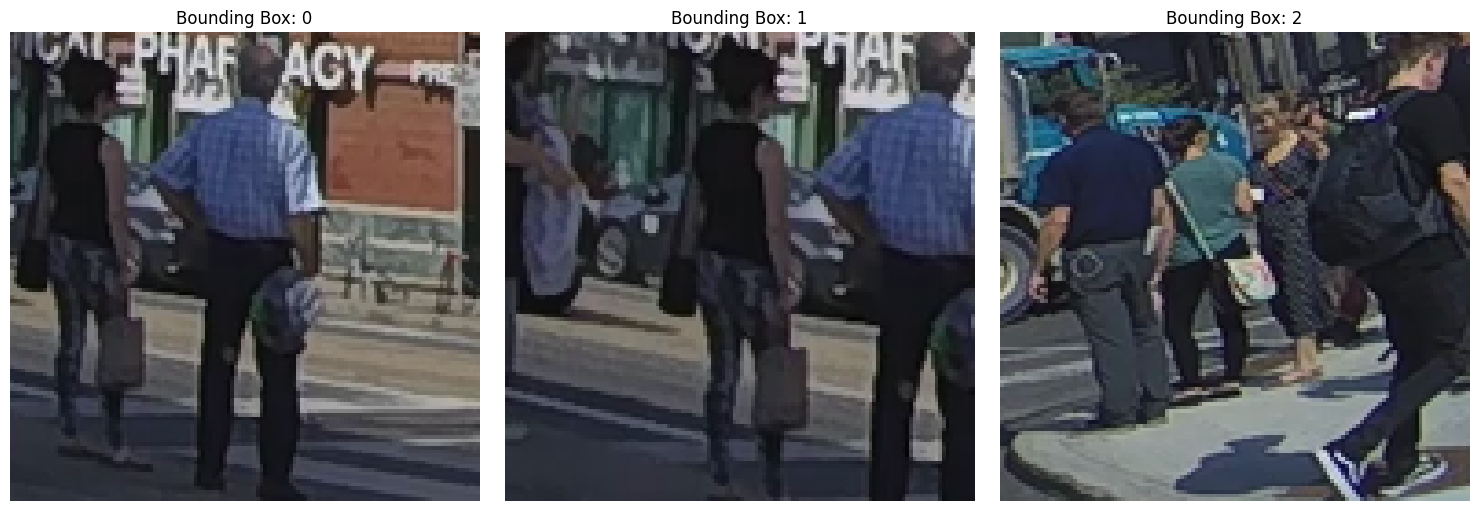

In [40]:
from PIL import Image
from preprocessors import BoundingBoxEngineering
import matplotlib.pyplot as plt

imgs = ["C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/set01/video_0002/11700.png"]
boxes = 3
bb = BoundingBoxEngineering(
    dsample=128,
    max_boxes=boxes
)
results = bb.transform(imgs)

fig, axes = plt.subplots(1, boxes, figsize=(15, 5))

# 3. Loop through the paths and axes to plot
for i in range(boxes):
    img = (results[0,i,:,:,:3] * 255).astype(np.uint8)
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide ticks and labels
    axes[i].set_title(f"Bounding Box: {i}") # Optional: set title to filename

plt.tight_layout()
plt.show()

# Metadata embeddings

The results from this process include the X, Y coordinates as well as the width, height and label for each bounding box. To inspect them use the operations.

```python
# Returns a single bounding box from a single frame
results[0, 0, :, :, :3].shape
>>> (224, 224, 3)

# Returns a first bounding box from all frames
results[:, 0, :, :, :3].shape
>>> (1, 224, 224, 3)

# Returns a all bounding box from first frames
results[0, :, :, :, :3].shape
>>> (3, 224, 224, 3)

# Returns a single bounding box channel from first frames
results[0, 0, :, :, 0].shape
>>> (224, 224)

# Returns metadata channels from the first bounding box and frame
results[0, 0, 0, 0, 3:].shape
>>> (5,)

# Returns x,y coordinate channels from all first bounding box and frame
results[0, :, 0, 0, 3:5]
>>> [[    0.22701     0.76297]
     [     0.1956     0.75651]
     [    0.98263     0.72298]]

# Returns width and height channels from all first bounding box and frame
results[0, :, 0, 0, 5:7]
>>> [[   0.030825     0.16371]
     [   0.024894     0.14171]
     [   0.034265     0.28295]]

# Returns classes (1 = pedestrian, -1 = traffic-light) channels from all first bounding box and frame
results[0, :, 0, 0, 7]
>>> [          1           1           1]
```

# Training data

The training data was collected and by stored in a .dat file. The file does not conform the the size requirements of github, therefore, to download this file from google drive. 

https://drive.google.com/file/d/1cfljLL83tJgT8vLEiIPhPYl8BonuMaw6/view?usp=drive_link

To access the various labels to predict:
```python
# The columns correspond to: 'occlusion','state','action','gesture','cross','look'
training[:,0,0,0,8:14]
```

In [ ]:
import os
import numpy as np

path = "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/bboxes.csv"
annot = pd.read_csv(path,converters={ 'frame': lambda x: f"{int(x):05d}", 'id': str })

folder_path = r"C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/cropped"
imgs = [f"{folder_path}/{f}" for f in os.listdir(folder_path)]

bb = BoundingBoxEngineering(batch_size=10, max_boxes=1)
results = bb.transform(imgs)

files = pd.DataFrame([file.split('/')[-1].split('.')[0].split('-') for file in imgs], columns=['video', 'frame', 'content', 'id'])
files = files.merge(annot, on=['video', 'frame', 'content', 'id'], how='left').fillna(0)

labels = files[['occlusion','state','action','gesture','cross','look']].values.astype(np.float32)
labels_broadcasted = np.broadcast_to(labels[:, np.newaxis, np.newaxis, np.newaxis, :], (68700, 1, 128, 128, 6))

# data = np.concatenate([results, labels_broadcasted], axis=-1)
np.save('C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-frames.npy', results)

In [ ]:
path = '.../vectorized-video-frames-labelled.bin'
results = np.memmap(path, dtype='float32', mode='r', shape=(68700, 1, 128, 128, 14))

In [49]:
import numpy as np

# 1. Define final shape and path
final_shape = (68700, 1, 128, 128, 14)
file_path = 'C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-frame-2.bin'

# 2. Create the file on disk (w+ means write/create)
# This will take up 58.7 GiB of disk space immediately
data_mmap = np.memmap(file_path, dtype='float32', mode='w+', shape=final_shape)

# 3. Insert 'results' into the first 8 channels
data_mmap[..., :8] = results
data_mmap.flush()  # Forces write to disk

# 4. Insert labels into the last 6 channels
# We do this in one step because labels_broadcasted already exists in your RAM
data_mmap[..., 8:] = labels_broadcasted
data_mmap.flush()

print(f"Success! Data saved to {file_path}")

Success! Data saved to C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-frame-2.bin


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from typing import List, Tuple
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class ConvolutionalNeuralNetwork(nn.Module, BaseEstimator, TransformerMixin):
    def __init__(
            self,
            epoch: int = 10,
            learning_rate: float = 0.1,
            layers: List[torch.nn.Module] = [],
            criterion: str = 'CrossEntropyLoss',
            optimizer: str = 'Adam',
            batch_size: int = 100,
            minimum_change: float = 0.0,
            seed: int = 0
        ):
        super(ConvolutionalNeuralNetwork, self).__init__()

        if layers is None:
            raise ValueError("Need layers bro!")

        self.losses: List[float] = []
        self.epoch: int = epoch
        self.learning_rate: float = learning_rate
        self.layers: List[torch.nn.Module] = nn.Sequential(*layers)
        self.criterion: str = criterion
        self.optimizer: str = optimizer
        self.batch_size: int = batch_size
        self.minimum_change: float = minimum_change
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.seed: int = seed
        torch.manual_seed(self.seed)

    def forward(self, X: np.ndarray) -> np.ndarray:
        return self.layers(X)

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Extracts deep features from the image channels (0-2) and 
        concatenates them with the metadata (3-7).
        """
        # 1. Separate Images and Metadata
        # Images: (N, 224, 224, 0:3) | Metadata: (N, 224, 224, 3:8)
        images = torch.tensor(X[:, :, :, :3], dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)
        
        # Extract metadata from the first pixel of each crop (since it's tiled)
        metadata = X[:, 0, 0, 3:] 

        self.eval()
        with torch.no_grad():
            # 2. Pass through the CNN layers
            features = self.forward(images)
            
            # 3. Flatten the spatial dimensions if the CNN output is still 4D
            # (Batch, Channels, 1, 1) -> (Batch, Channels)
            flat_features = torch.flatten(features, start_dim=1).cpu().numpy()

        # 4. Concatenate Smart Features with Raw Metadata
        return np.concatenate([flat_features, metadata], axis=1)

    def fit_transform(self, X: np.ndarray, y: np.array = None) -> np.ndarray:
        self.fit(X, y)
        return self.transform(X)

    def fit(self, X: np.ndarray, y: np.array) -> np.ndarray:
        y = torch.tensor(y, dtype=torch.long).to(self.device)
        X = torch.tensor(X[:, :, :, :3], dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)

        criterion = getattr(torch.nn, self.criterion)()
        optimizer = getattr(torch.optim, self.optimizer)(self.parameters(), lr=self.learning_rate, weight_decay=0.001)

        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        for _ in tqdm(range(self.epoch)):
            loss: float = 0.0
            for X_batch, y_batch in dataloader:
                # Forward pass
                y_batch_pred = self.forward(X_batch)
                batch_loss = criterion(y_batch_pred, y_batch)
                loss += batch_loss.item()

                # Backward and optimize
                optimizer.zero_grad()
                batch_loss.backward()
                optimizer.step()
            self.losses.append(loss / len(dataloader))
            if len(self.losses) > 1 and abs(self.losses[-2] - self.losses[-1]) <= self.minimum_change:
                break

        print("Loss: {}".format(self.losses[-1]))
        return self